# 10 - Pixel-space generative prior (score-based DA)

An unconditional diffusion model trained on the LOVECLIM anomaly fields replaces
the Gaussian background of 3DVar. Reconstruction is guided posterior sampling: the
EDM reverse process plus an observation-guidance score `grad log p(y | x_sigma)`
from the Gaussian likelihood `N(y; H x_hat, S(sigma))`, with
`x_hat = D(x_sigma; sigma)` and

    S(sigma) = gamma * H Sigma(sigma) H^T + R,

the annealed tapered background covariance at the observed cells: `Sigma(sigma)`
shrinks each eigenvalue `lam` of B to `lam sigma^2 / (lam + sigma^2)`, so S runs
from `gamma * H B H^T + R`, the 3DVar innovation covariance, at high noise down to
`R` as `sigma -> 0`, and clustered sites share their evidence instead of counting
as independent (Manshausen et al. 2025; Rozet and Louppe 2023; Chung et al. 2023;
Boys et al. 2023).

Two priors mirror the compressors: the older chronological half for the same-model
PPE lane, all ages for the withholding lane. `LANES` selects which of the two run,
and the priors to train follow from it. `gamma` (the multiplier on the prior block
of S, 1 by the Gaussian derivation) is the tuned operating point, selected on the
held-out split and reported on the test split, so results land in
`outputs/da/generative/` on the same schema notebook 09 compares.

A hybrid variant anchors the score's Gaussian part to the tapered B: at or
above a switch noise level the denoiser is the closed-form Gaussian denoiser
of `N(0, amp * B)` (the net is essentially untrained there), below it the
trained net, and the guidance shares the same amp-scaled covariance.
`HYBRID_LANES` selects its lanes; `(amp, sigma_switch, gamma)` are tuned
jointly on the selection split and results land in
`outputs/da/generative_hybrid/` as their own method row.

In [3]:
%load_ext autoreload
%autoreload 2

import os
for _v in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS",
           "NUMEXPR_NUM_THREADS", "VECLIB_MAXIMUM_THREADS"):
    os.environ[_v] = "1"

import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

sys.path.insert(0, os.path.abspath(".."))

from paleoreco.data import build_prior_cube, VARS
from paleoreco.data.cube import apply_anomaly, compute_zscore_stats
from paleoreco.data.splits import chronological_half_split
from paleoreco.assim.observations import (
    attach_site_stats, collapse_to_samples, load_observations, observation_site_stats,
)
from paleoreco.models.diffusion import CircularUNet, EDMDenoiser, load_denoiser, SIGMA_DATA
from paleoreco.training import trainer_diffusion as td
from paleoreco.assim.generative import (
    GuidedSampler, HybridDenoiser, cell_scales, guidance_cov,
)
from paleoreco.assim.priors import build_prior
from paleoreco.assim.sampler_pool import SamplerPool
from paleoreco.assim import experiments_generative as gex
from paleoreco.eval import da

plt.rcParams["figure.dpi"] = 110
DATA = "../data"
OUT = Path("../outputs/da")
CKPT = Path("../outputs/checkpoints/10_generative_prior")
FIG = Path("../outputs/figures/10_generative_prior")
CKPT.mkdir(parents=True, exist_ok=True)
FIG.mkdir(parents=True, exist_ok=True)

DEVICE = ("cuda" if torch.cuda.is_available()
          else "mps" if torch.backends.mps.is_available() else "cpu")

# Which lanes to run, for the plain prior and for the B-anchored hybrid sweep;
# the priors to train follow from the union, so an inconsistent set cannot be
# expressed. Each is a subset of ("ppe", "withholding").
LANES = ("ppe", )
HYBRID_LANES = ("ppe",)
TRUTH_STRIDE = 10                       # ppe lane
FOLD_KIND, AGE_STRIDE = "random", 6     # withholding lane

LANE_PRIOR = {"ppe": "chunkA", "withholding": "full"}
LANE_NAME = {"ppe": "ppe", "withholding": f"withholding_{FOLD_KIND}"}
# Guidance covariance taper per lane: each lane's 3DVar-selected pixel config, so
# the guidance weighs observations with the covariance its baseline trusts.
GUIDANCE_TAPER = {
    "ppe": dict(localization_km=15000.0, shrinkage_lambda=0.0, alpha=0.25),
    "withholding": dict(localization_km=None, shrinkage_lambda=0.5, alpha=0.5),
}
PRIORS = sorted({LANE_PRIOR[lane] for lane in (*LANES, *HYBRID_LANES)})
print("device:", DEVICE, "| lanes:", LANES, "| hybrid:", HYBRID_LANES,
      "| priors:", PRIORS)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
device: cuda | lanes: ('ppe',) | hybrid: ('ppe',) | priors: ['chunkA']


## Prior cube, chronological split, and the normalised anomaly frames

Each frame is the per-cell anomaly over its own ages, rescaled **per cell** to std
`SIGMA_DATA`, the scale the EDM recipe expects. The states, the climatology and the
scale field all come from those ages, so the PPE prior never sees the younger truths.

Scaling per cell rather than per channel leaves unit variance everywhere, so the
network learns correlation structure and the spatial variance pattern is carried by
the scale field instead. Two consequences follow and are worth holding in view when
reading the results below. The prior's variance geography is imposed rather than
learned, so its marginal per-cell variances come from the same empirical source
`diag(B)` does. And the network spends equal capacity on climatically inert cells and
on the North Atlantic centre carrying the D-O signal, which may cost skill even where
it helps calibration.

In [4]:
P = build_prior_cube(prior_csv=f"{DATA}/Prior.csv", cache_path=f"{DATA}/cache/prior_cube.npz")
cube, ages, lats, lons, valid = P["cube"], P["ages"], P["lats"], P["lons"], P["valid"]

all_idx = np.arange(len(ages))
prior_idx, truth_idx = chronological_half_split(ages, stride=TRUTH_STRIDE)
PRIOR_IDX = {"chunkA": prior_idx, "full": all_idx}

long_ppe = load_observations(f"{DATA}/Observation.csv")
long_wh = attach_site_stats(long_ppe, observation_site_stats(collapse_to_samples(long_ppe)))


def frame(idx):
    """safe_valid mask, per-cell scale field, and the SIGMA_DATA-scaled anomaly cube over ``idx``.

    The cube is restricted to ``idx`` after centring, so the states, the climatology
    and the scale field all come from the same ages.
    """
    stats = compute_zscore_stats(cube, idx, valid)
    anom = apply_anomaly(cube, stats)[idx]
    scales = cell_scales(anom, stats["safe_valid"])
    norm = anom * (SIGMA_DATA / scales)
    return stats["safe_valid"], scales, anom.astype(np.float64), norm.astype(np.float32)


FRAME = {name: frame(PRIOR_IDX[name]) for name in PRIORS}
print("cube", cube.shape, "| sites", long_ppe["site"].nunique())
for name, (safe, scales, _, norm) in FRAME.items():
    print(f"{name}: {norm.shape[0]} states | per-cell scale "
          f"{scales[:, safe].min():.3f} to {scales[:, safe].max():.3f} degC "
          f"| normalised per-cell std {norm[:, :, safe].std(axis=0).mean():.3f} "
          f"(target {SIGMA_DATA})")

cube (804, 2, 32, 64) | sites 187
chunkA: 402 states | per-cell scale 0.092 to 6.839 degC | normalised per-cell std 0.500 (target 0.5)


## Train the diffusion priors

Small U-Net, EDM denoising-score-matching with EMA. Data is scarce (hundreds of
autocorrelated states), so the epoch count is selected rather than fixed: each prior
first *searches* on a random 75/25 split, stopping once the held-out score has not
improved for `PATIENCE` epochs, then *refits* on every state up to the best epoch.

The held-out score is the EDM loss on a fixed grid of noise levels with fixed noise,
not the training loss: the training loss draws a random noise level per sample, and
that spread is far larger than the epoch-to-epoch change early stopping has to
resolve. It scores the EMA weights, since those are what the checkpoint saves and
the sampler loads.

The refit keeps the cosine horizon at `EPOCHS`, so it follows the same learning-rate
trajectory the search selected on and the chosen epoch keeps its meaning. Set
`RETRAIN = False` once the checkpoints exist to skip both phases; a checkpoint left
over from a different scale frame is retrained regardless, since its weights are not
usable in this one.

In [5]:
RETRAIN = False
EPOCHS, BASE, DEPTH, LR, BATCH = 3000, 64, 2, 2e-4, 64
VAL_FRACTION, PATIENCE, SPLIT_SEED = 0.25, 50, 0
T0 = time.time()


def _net():
    return EDMDenoiser(CircularUNet(base_channels=BASE, depth=DEPTH,
                                    grid_shape=tuple(cube.shape[2:])))


def checkpoint_path(name):
    return CKPT / f"diffusion_{name}.pt"


def _frame_matches(path, shape):
    """Whether a checkpoint was trained in the scale frame about to be used.

    A checkpoint from a different frame would otherwise be kept and then fail when
    the sampler loads it, so a stale one is retrained rather than skipped.
    """
    try:
        return np.shape(torch.load(path, map_location="cpu").get("scales")) == shape
    except Exception:
        return False


def train_prior(name):
    """Select the epoch count on a held-out split, then refit on every state."""
    safe, scales, _, norm = FRAME[name]
    path = checkpoint_path(name)
    if path.exists() and not RETRAIN and _frame_matches(path, scales.shape):
        print("exists:", path.name)
        return None

    perm = np.random.default_rng(SPLIT_SEED).permutation(len(norm))
    n_val = int(round(VAL_FRACTION * len(norm)))
    val_idx, train_idx = perm[:n_val], perm[n_val:]

    print(f"[{name}] search | {len(train_idx)} train / {len(val_idx)} val "
          f"| max {EPOCHS} ep, patience {PATIENCE}", flush=True)
    t = time.time()
    search = td.train(_net(), norm[train_idx], safe, val_cube=norm[val_idx],
                      patience=PATIENCE, max_epochs=EPOCHS, batch_size=BATCH,
                      lr=LR, device=DEVICE, seed=0)
    n_star = search["best_epoch"] + 1          # 0-based index -> epoch count
    print(f"[{name}] search | done in {time.time() - t:.0f}s "
          f"| best ep {search['best_epoch']} | stopped at {search['stop_epoch']} "
          f"| early={search['stopped_early']} | refit to {n_star}", flush=True)

    print(f"[{name}] refit | {n_star} ep on {len(norm)} states", flush=True)
    t = time.time()
    td.train(_net(), norm, safe, max_epochs=n_star, lr_schedule_epochs=EPOCHS,
             batch_size=BATCH, lr=LR, device=DEVICE, checkpoint_path=str(path),
             scales=scales, seed=0,
             checkpoint_extra={"selection": {
                 "best_epoch": int(search["best_epoch"]),
                 "stop_epoch": int(search["stop_epoch"]),
                 "refit_epochs": int(n_star),
                 "stopped_early": bool(search["stopped_early"]),
                 "patience": int(PATIENCE), "val_fraction": float(VAL_FRACTION),
                 "split_seed": int(SPLIT_SEED), "max_epochs": int(EPOCHS)}})
    print(f"[{name}] refit | done in {time.time() - t:.0f}s | wrote {path.name}", flush=True)

    np.savez(CKPT / f"{path.stem}_search.npz",
             **{k: np.asarray(v) for k, v in search["history"].items()})
    return search


SEARCH = {name: train_prior(name) for name in PRIORS}
print(f"total {time.time() - T0:.0f}s")

exists: diffusion_chunkA.pt
total 0s


### Search curves

Red marks where early stopping halted the search, grey the best epoch the refit used.
On the left all three curves are the same fixed-grid score, so the gap between the
training probe and the held-out curve is the generalisation gap, and the gap between
the EMA and live curves is the lag introduced by weight averaging. The right panel is
the random-sigma quantity actually minimised, which sits on its own scale.

If the probe and held-out curves sit on top of each other and never separate, the
random split has no detection power on states this autocorrelated, and the result is
inconclusive rather than evidence of no overfitting.

In [4]:
from paleoreco.eval.diffusion import plot_loss_curves_diffusion

for name, search in SEARCH.items():
    if search is None:
        continue
    plot_loss_curves_diffusion(
        search["history"], best_epoch=search["best_epoch"],
        stop_epoch=search["stop_epoch"] - 1, title=f"{name} prior",
        save_path=str(FIG / f"loss_curves_{name}.png"))
    plt.show()

## Build the samplers

One sampler per trained prior for the diagnostics below. The lanes themselves run on
a `SamplerPool`, built and closed around each lane: a single posterior draw occupies
a fraction of the GPU, so spreading independent draws over `N_WORKERS` processes is
most of the run's wall clock. Every draw carries its own seed, so the pooled result
is the serial one.

Each sampler and pool takes a guidance covariance: the lane's tapered background
covariance, moved into the checkpoint's per-cell frame and eigendecomposed once
(`guidance_cov`). The taper is the lane's 3DVar-selected config, so the guidance
weighs observations with the covariance the baseline trusts, and the PPE lane's
covariance never sees the younger truths. `PRIOR_VAR`, the per-cell variance of
unconditional draws, remains as a diagnostic: the analysis npz and the spread
figures read it, the likelihood does not.

Ensemble sizes are asymmetric. Below about 16 members a draw costs what one member
costs, so `K_SELECT` is free; the reported `K` is larger because averaging a finite
ensemble inflates the error by `mean(post_var) / K`, and 3DVar carries no such term.

In [6]:
N_STEPS = 64
GAMMA_GRID = gex.GAMMA_GRID
AMP_GRID, SWITCH_GRID = gex.AMP_GRID, gex.SWITCH_GRID
HYBRID_GAMMA_GRID = gex.HYBRID_GAMMA_GRID
K, K_SELECT = 256, 16
N_WORKERS = 1
N_PRIOR_VAR = 512
# max_batch: a K=256 guided draw in one batch peaks near 4 GiB on the shared
# card (the guidance backward pass stores activations for the whole batch);
# chunks of 64 draw the same i.i.d. ensemble within ~1.5 GiB.
MAX_BATCH = 64
SAMPLER_KW = dict(n_samples=K, n_steps=N_STEPS, max_batch=MAX_BATCH, device=DEVICE)


def load_sampler(name, cov):
    net, scales = load_denoiser(str(checkpoint_path(name)))
    return GuidedSampler(net, np.asarray(scales), FRAME[name][0], cov, **SAMPLER_KW)


# One guidance covariance per lane prior, in that checkpoint's own frame. The eigh
# runs single-threaded (BLAS threads are pinned above) and costs about a minute.
COV = {}
for lane in sorted(set(LANES) | set(HYBRID_LANES)):
    name = LANE_PRIOR[lane]
    prior_b = build_prior(cube, ages, lats, lons, PRIOR_IDX[name], valid,
                          **GUIDANCE_TAPER[lane])
    COV[name] = guidance_cov(prior_b.B, FRAME[name][1], FRAME[name][0],
                             meta={"prior": name, **prior_b.meta})

SAMPLER = {name: load_sampler(name, COV[name]) for name in PRIORS}


def prior_var_map(name, n=N_PRIOR_VAR, seed=0):
    """Per-cell prior variance from ``n`` unconditional draws, anomaly units.

    Diagnostic only: the analysis npz and the spread figures read it, the guidance
    reads COV. Batched because an ensemble this size does not fit in one forward
    pass.
    """
    s = SAMPLER[name]
    ens = np.concatenate([s.sample_prior(64, seed=seed + k) for k in range(n // 64)])
    return ens.var(axis=0, ddof=1)


PRIOR_VAR = {name: prior_var_map(name) for name in PRIORS}

for name in PRIORS:
    safe, scales, _, _ = FRAME[name]
    pv = PRIOR_VAR[name][:, safe]
    print(f"{name}: prior std {np.sqrt(pv).mean():.3f} degC against a scale field of "
          f"{scales[:, safe].mean():.3f} | corr "
          f"{np.corrcoef(np.sqrt(pv).ravel(), scales[:, safe].ravel())[0, 1]:.3f}")

chunkA: prior std 0.794 degC against a scale field of 0.819 | corr 0.999


## Unconditional sanity: did the prior learn the climate?

Given the small training set, check that generated fields resemble real LOVECLIM
states (per-cell std, leading-PC score spread) and that the model is not
regurgitating training snapshots (nearest-neighbour distance).

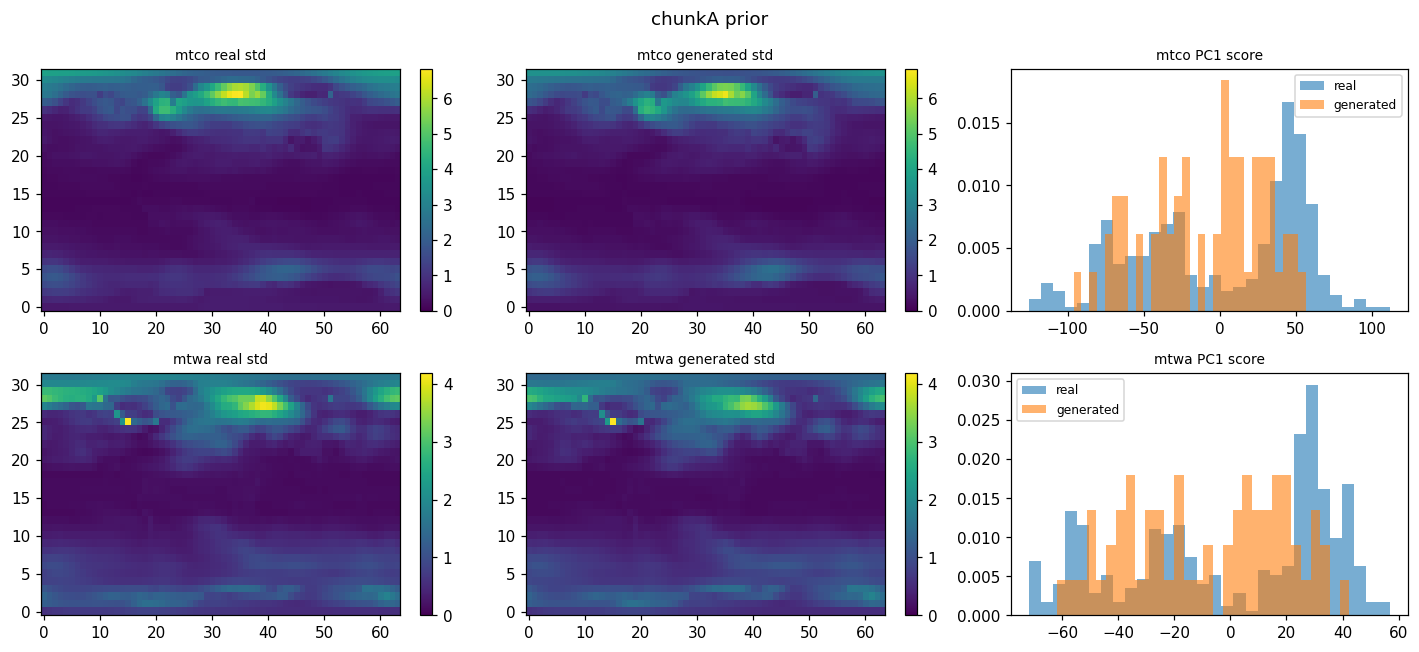

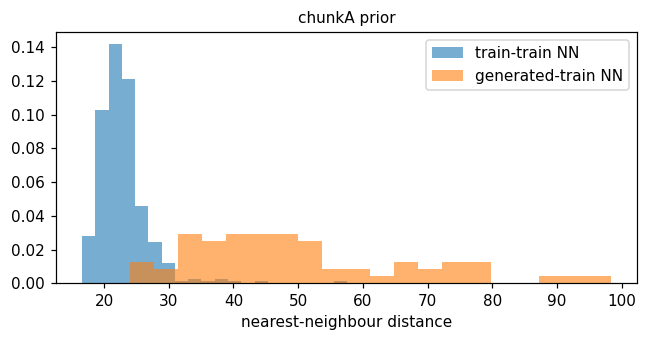

chunkA: median NN distance generated 46.224 | train 22.226


In [6]:
from scipy.spatial.distance import cdist

for name in PRIORS:
    safe, _, anom, _ = FRAME[name]
    real = anom[:, :, safe]
    gen = SAMPLER[name].sample_prior(64, seed=0)[:, :, safe]

    fig, axes = plt.subplots(2, 3, figsize=(13, 6))
    for c, ch in enumerate(VARS):
        vmax = float(real[:, c].std(0).max())
        for col, (title, field) in enumerate((("real std", real[:, c].std(0)),
                                              ("generated std", gen[:, c].std(0)))):
            m = np.full(safe.shape, np.nan); m[safe] = field
            ax = axes[c, col]
            im = ax.imshow(m, origin="lower", cmap="viridis", vmin=0, vmax=vmax,
                           aspect="auto")
            ax.set_title(f"{ch} {title}", fontsize=9)
            fig.colorbar(im, ax=ax, fraction=0.046)
        # leading-PC score distribution, generated vs real
        Xr = real[:, c] - real[:, c].mean(0)
        pc = np.linalg.svd(Xr, full_matrices=False)[2][0]
        axes[c, 2].hist(Xr @ pc, bins=30, density=True, alpha=0.6, label="real")
        axes[c, 2].hist((gen[:, c] - real[:, c].mean(0)) @ pc, bins=30, density=True,
                        alpha=0.6, label="generated")
        axes[c, 2].set_title(f"{ch} PC1 score", fontsize=9)
        axes[c, 2].legend(fontsize=8)
    fig.suptitle(f"{name} prior")
    fig.tight_layout()
    fig.savefig(FIG / f"unconditional_quality_{name}.png", bbox_inches="tight")
    plt.show()

    # Memorisation: nearest training state per generated sample against a train-train
    # baseline. cdist avoids the O(N^2 D) broadcast that would materialise tens of GB.
    gv, rv = gen.reshape(len(gen), -1), real.reshape(len(real), -1)
    d_gen = cdist(gv, rv).min(1)
    dd = cdist(rv, rv); np.fill_diagonal(dd, np.inf)
    d_train = dd.min(1)
    fig, ax = plt.subplots(figsize=(6, 3.2))
    ax.hist(d_train, bins=20, density=True, alpha=0.6, label="train-train NN")
    ax.hist(d_gen, bins=20, density=True, alpha=0.6, label="generated-train NN")
    ax.set_xlabel("nearest-neighbour distance"); ax.legend()
    ax.set_title(f"{name} prior", fontsize=10)
    fig.tight_layout(); fig.savefig(FIG / f"memorisation_{name}.png", bbox_inches="tight")
    plt.show()
    print(f"{name}: median NN distance generated {np.median(d_gen):.3f} "
          f"| train {np.median(d_train):.3f}")

## Run the generative lanes

PPE on the older-half prior, withholding on the all-ages prior, whichever `LANES`
selects. `gamma` is swept on the selection split and reported at its winner on the
test split; withholding is age-subsampled for cost (the stride is recorded in the
config). Results share the `outputs/da/generative/` schema, so notebook 09 compares
them against 3DVar.

Each lane clears only its own rows and files before running, so one lane can be run
now and the other added later without disturbing it. Each opens its own pool and
closes it before the next, so only one set of workers holds GPU memory at a time.
`progress_every` counts posterior draws, and the ETA covers a whole pass, so each
lane prints a selection block and a test block.

In [7]:
d = OUT / "generative"
t_lanes = time.time()

for lane in LANES:
    prior = LANE_PRIOR[lane]
    gex.clear_lane(str(d), LANE_NAME[lane])
    print(f"[{lane}] on the {prior} prior", flush=True)
    with SamplerPool(str(checkpoint_path(prior)), FRAME[prior][0], COV[prior],
                     n_workers=N_WORKERS, **SAMPLER_KW) as pool:
        if lane == "ppe":
            gex.run_ppe_generative(
                cube, ages, lats, lons, valid, long_ppe, str(d), sampler=pool,
                prior_ens_var=PRIOR_VAR[prior],
                gamma_grid=GAMMA_GRID, n_samples=K, n_samples_select=K_SELECT,
                truth_stride=TRUTH_STRIDE, progress_every=25)
        else:
            gex.run_withholding_generative(
                cube, ages, lats, lons, valid, long_wh, str(d), sampler=pool,
                gamma_grid=GAMMA_GRID, n_samples=K, n_samples_select=K_SELECT,
                fold_kind=FOLD_KIND, age_stride=AGE_STRIDE, progress_every=100)

print(f"{len(LANES)} lane(s) in {time.time() - t_lanes:.0f}s")
print("wrote", sorted(p.name for p in d.iterdir()))

[ppe] on the chunkA prior


  ppe selection draws 25/240 (10%, elapsed 37s, eta 320s)


  ppe selection draws 50/240 (21%, elapsed 74s, eta 282s)


  ppe selection draws 75/240 (31%, elapsed 111s, eta 244s)


  ppe selection draws 100/240 (42%, elapsed 148s, eta 207s)


...

  ppe selection draws 175/240 (73%, elapsed 259s, eta 96s)


  ppe selection draws 200/240 (83%, elapsed 295s, eta 59s)


  ppe selection draws 225/240 (94%, elapsed 332s, eta 22s)


  ppe test draws 25/41 (61%, elapsed 386s, eta 247s)


1 lane(s) in 1022s
wrote ['metrics.csv', 'ppe_analysis.npz', 'ppe_config.json']


## Run the hybrid sweep: anchor the score's Gaussian part to B

The learned score is essentially untrained above `sigma ~ 3` (the training
lognormal puts ~2% of its mass there) yet half the sampling trajectory runs
there, which is where the leading modes' variance is set. The hybrid denoiser
substitutes the closed-form Gaussian denoiser of `N(0, amp * B_tapered)` at or
above `sigma_switch` and keeps the net below; the guidance takes the same
amp-scaled covariance (`COV[prior].scaled(amp)`), so prior and likelihood stay
moment-matched by construction.

`(amp, sigma_switch, gamma)` are tuned jointly on the selection split, one pool
per `(amp, switch)` so a single set of workers holds the GPU at a time, and only
the winner runs the test split. `HYBRID_LANES` selects the lanes independently of
the plain runs above; artefacts land in `outputs/da/generative_hybrid/` as
`method="generative_hybrid"`.

In [8]:
d_hyb = OUT / "generative_hybrid"
t_hyb = time.time()

for lane in HYBRID_LANES:
    prior = LANE_PRIOR[lane]
    gex.clear_lane(str(d_hyb), LANE_NAME[lane])
    print(f"[{lane} hybrid] on the {prior} prior", flush=True)

    def make_hybrid_pool(amp, switch, prior=prior):
        return SamplerPool(str(checkpoint_path(prior)), FRAME[prior][0],
                           COV[prior].scaled(amp), sigma_switch=switch,
                           n_workers=N_WORKERS, **SAMPLER_KW)

    if lane == "ppe":
        gex.run_ppe_generative_hybrid(
            cube, ages, lats, lons, valid, long_ppe, str(d_hyb),
            make_sampler=make_hybrid_pool, amp_grid=AMP_GRID,
            switch_grid=SWITCH_GRID, gamma_grid=HYBRID_GAMMA_GRID,
            n_samples=K, n_samples_select=K_SELECT, n_prior_var=N_PRIOR_VAR,
            truth_stride=TRUTH_STRIDE, progress_every=25)
    else:
        gex.run_withholding_generative_hybrid(
            cube, ages, lats, lons, valid, long_wh, str(d_hyb),
            make_sampler=make_hybrid_pool, amp_grid=AMP_GRID,
            switch_grid=SWITCH_GRID, gamma_grid=HYBRID_GAMMA_GRID,
            n_samples=K, n_samples_select=K_SELECT,
            fold_kind=FOLD_KIND, age_stride=AGE_STRIDE, progress_every=100)

print(f"{len(HYBRID_LANES)} hybrid lane(s) in {time.time() - t_hyb:.0f}s")
if d_hyb.exists():
    print("wrote", sorted(p.name for p in d_hyb.iterdir()))

[ppe hybrid] on the chunkA prior


  hybrid selection draws (amp=1, switch=0.5) 25/144 (17%, elapsed 21s, eta 100s)


  hybrid selection draws (amp=1, switch=0.5) 50/144 (35%, elapsed 41s, eta 77s)


  hybrid selection draws (amp=1, switch=0.5) 75/144 (52%, elapsed 61s, eta 56s)


  hybrid selection draws (amp=1, switch=0.5) 100/144 (69%, elapsed 80s, eta 35s)


...

  hybrid selection draws (amp=2, switch=4) 75/144 (52%, elapsed 76s, eta 70s)


  hybrid selection draws (amp=2, switch=4) 100/144 (69%, elapsed 101s, eta 45s)


  hybrid selection draws (amp=2, switch=4) 125/144 (87%, elapsed 127s, eta 19s)


  hybrid test draws 25/41 (61%, elapsed 146s, eta 94s)


1 hybrid lane(s) in 1561s
wrote ['metrics.csv', 'ppe_analysis.npz', 'ppe_config.json']


### Hybrid selection surface and prior variance repair

The selection surface over `(sigma_switch, gamma)` per amplitude, and the per-PC
prior variance ratio at the winner. The plain prior samples PC1 well under its
true variance; pinning the high-noise regime to `amp * B` is exactly the part of
the hybrid that should pull it toward 1.

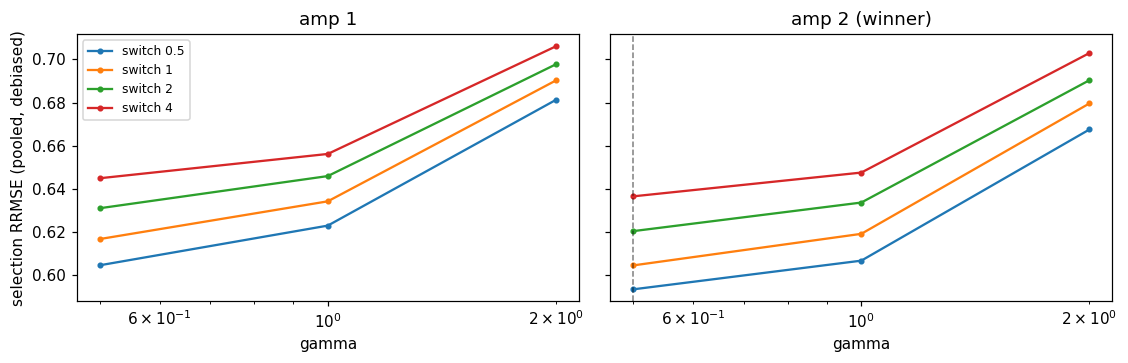

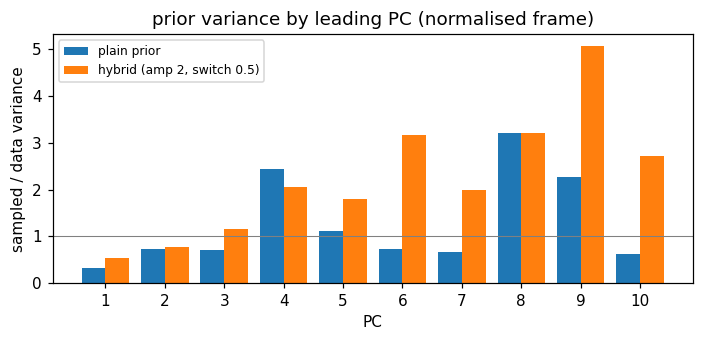

PC1-5 ratio plain : [0.33 0.73 0.7  2.45 1.12] | hybrid: [0.54 0.77 1.17 2.06 1.79]


In [9]:
_hd = OUT / "generative_hybrid"
if "ppe" in HYBRID_LANES and (_hd / "ppe_analysis.npz").exists():
    import json

    Mh = pd.read_csv(_hd / "metrics.csv")
    sel = Mh[(Mh.lane == "ppe") & (Mh.split == "selection") & (Mh.channel == "pooled")
             & (Mh.do_event == "all") & (Mh.metric == "rrmse_ens")]
    win = json.load(open(_hd / "ppe_config.json"))["selected"]

    amps = sorted(sel["hybrid_amp"].unique())
    fig, axes = plt.subplots(1, len(amps), figsize=(5.2 * len(amps), 3.4),
                             sharey=True, squeeze=False)
    for ax, amp in zip(axes[0], amps):
        for sw, grp in sel[sel.hybrid_amp == amp].groupby("hybrid_switch"):
            grp = grp.sort_values("b_scale")
            ax.plot(grp["b_scale"], grp["value"], "o-", ms=3, label=f"switch {sw:g}")
        ax.set_xscale("log")
        if amp == win["hybrid_amp"]:
            ax.axvline(win["b_scale"], color="k", lw=1, ls="--", alpha=0.5)
        ax.set_title(f"amp {amp:g}" + (" (winner)" if amp == win["hybrid_amp"] else ""))
        ax.set_xlabel("gamma")
    axes[0, 0].set_ylabel("selection RRMSE (pooled, debiased)")
    axes[0, 0].legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(FIG / "hybrid_selection_surface.png", bbox_inches="tight")
    plt.show()

    # Per-PC sampled-vs-data variance, winner hybrid against the plain prior, in
    # the normalised frame the denoiser works in.
    prior = LANE_PRIOR["ppe"]
    safe, scales, _, norm = FRAME[prior]
    cov_w = COV[prior].scaled(win["hybrid_amp"])
    hyb = HybridDenoiser(SAMPLER[prior].denoiser, cov_w, win["hybrid_switch"])
    samp_h = GuidedSampler(hyb, scales, safe, cov_w, **SAMPLER_KW)

    A = norm.reshape(len(norm), -1).astype(np.float64)
    A = A - A.mean(axis=0, keepdims=True)
    _, sd_, Vt = np.linalg.svd(A, full_matrices=False)
    data_var = sd_ ** 2 / (len(A) - 1)
    mult = (SIGMA_DATA / scales).ravel()

    def pc_ratio(sampler, seed0):
        ens = np.concatenate([sampler.sample_prior(64, seed=seed0 + k) for k in range(2)])
        E = ens.reshape(len(ens), -1) * mult[None, :]
        return (E @ Vt.T).var(axis=0, ddof=1) / data_var

    r_h, r_p = pc_ratio(samp_h, 200), pc_ratio(SAMPLER[prior], 200)
    n_pc = 10
    x = np.arange(1, n_pc + 1)
    fig, ax = plt.subplots(figsize=(6.5, 3.2))
    ax.bar(x - 0.2, r_p[:n_pc], 0.4, label="plain prior")
    ax.bar(x + 0.2, r_h[:n_pc], 0.4,
           label=f"hybrid (amp {win['hybrid_amp']:g}, switch {win['hybrid_switch']:g})")
    ax.axhline(1.0, color="grey", lw=0.7)
    ax.set_xlabel("PC")
    ax.set_ylabel("sampled / data variance")
    ax.set_xticks(x)
    ax.legend(fontsize=8)
    ax.set_title("prior variance by leading PC (normalised frame)")
    fig.tight_layout()
    fig.savefig(FIG / "hybrid_pc_variance_ratio.png", bbox_inches="tight")
    plt.show()
    print("PC1-5 ratio plain :", r_p[:5].round(2), "| hybrid:", r_h[:5].round(2))

### Is the sampled distribution Gaussian? PC score marginals

The prior variance ratios above say whether the second moment is right. This asks
the different question the method is motivated by: is what the sampler draws a
multivariate Gaussian at all?

By the Cramer-Wold device a distribution is multivariate Gaussian only if *every*
1-D projection of it is univariate Gaussian, so one visibly non-Gaussian projection
falsifies a Gaussian model of the samples. The projections used here are the leading
principal components **of each model's own samples**, not of the LOVECLIM states: the
question is whether the generated distribution is Gaussian, independent of whether it
matches the data's own structure. PCA maximises variance rather than non-Gaussianity,
so it cannot manufacture bimodality out of Gaussian samples; a bimodal or flat-topped
leading component is therefore evidence, not an artefact of the basis.

Two figures, one for the unconditional prior and one for the posterior of a single
assimilation, each carrying the four leading components as rows and the plain and
hybrid priors as columns. Every model sits at its own selected operating point, read
from its own `ppe_config.json`, and the posterior columns share one truth, network
and observation vector so they are paired. For reference the LOVECLIM states these
priors were trained on have PC1 excess kurtosis -1.19 and a two-component mixture
preferred over one by a BIC margin of 220.

Read the two asymmetrically. A non-Gaussian posterior proves the method carries
non-Gaussian structure through the update. A Gaussian-looking posterior does not
prove the opposite: with this many observations the posterior concentrates and Bayes'
rule drives it toward Gaussian regardless of the prior's shape, and a non-Gaussian
prior can still shift a unimodal posterior's *mean* toward the right regime, which is
where skill would come from.

The hybrid column has a structural expectation attached. Above `sigma_switch` its
denoiser is a linear operator and the guidance step is affine, so the trajectory from
initialisation down to the switch is an affine map of Gaussian noise and is exactly
Gaussian by construction; at the selected switch of 0.5 that covers 42 of the 64
levels. Only the levels below it can introduce non-Gaussianity, and by then the
leading modes are frozen (the shrinkage factor on PC1 at `sigma = 0.47` is 0.9995).
A Gaussian leading component in that column is therefore a statement about the
design choice, not about the trained network, which is what the plain column
separates out.

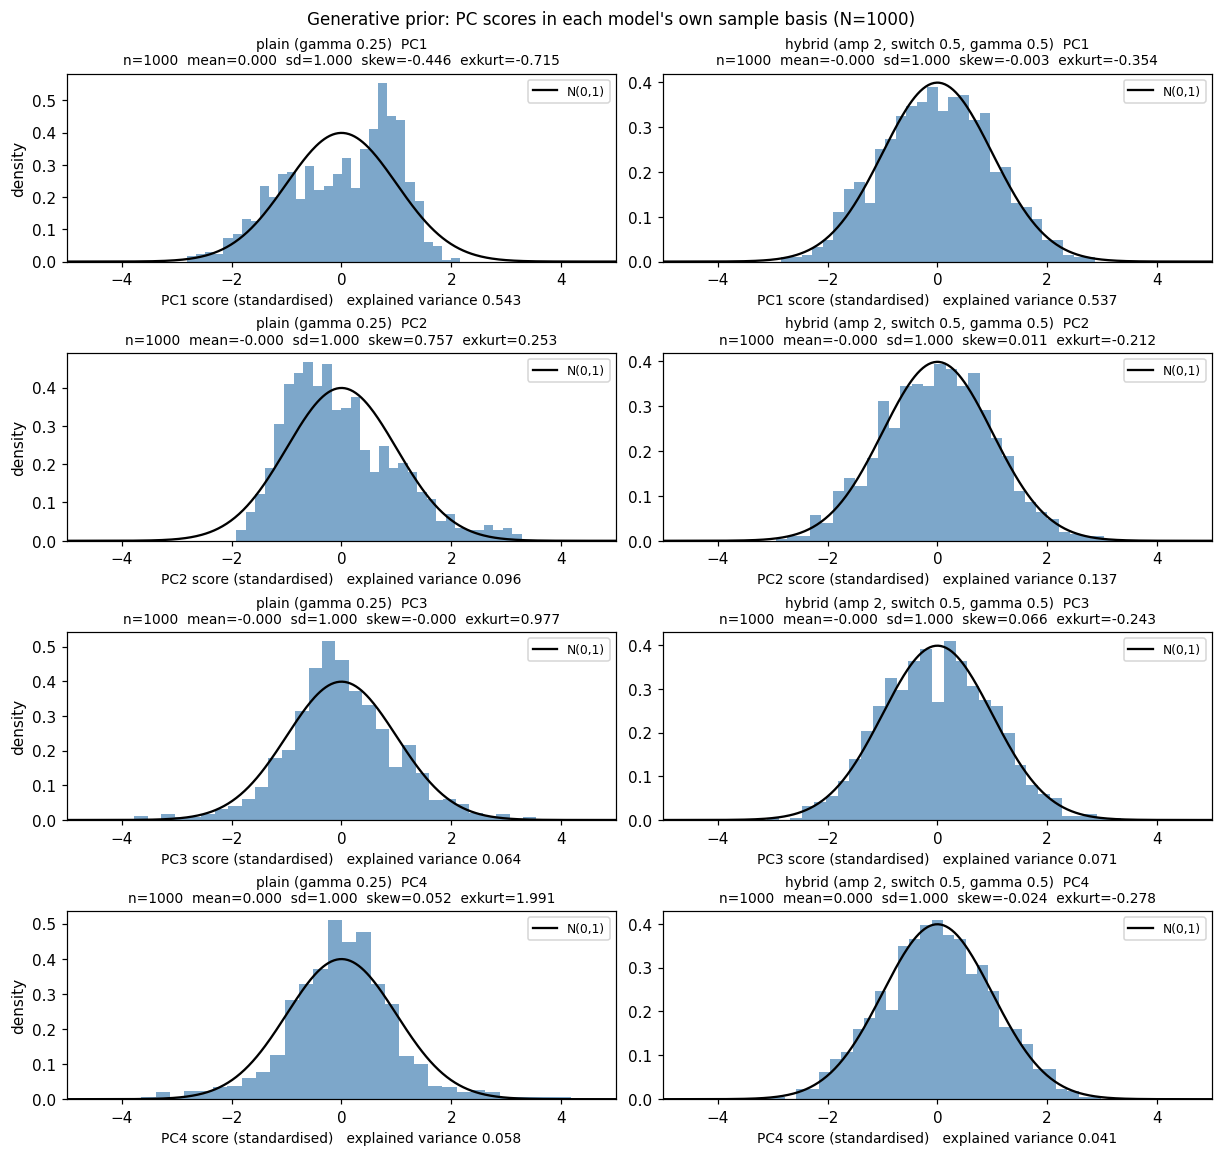

prior     | plain (gamma 0.25): PC1 evr 0.543 skew -0.45 exkurt -0.72 | PC2 evr 0.096 skew +0.76 exkurt +0.25 | PC3 evr 0.064 skew -0.00 exkurt +0.98 | PC4 evr 0.058 skew +0.05 exkurt +1.99
prior     | hybrid (amp 2, switch 0.5, gamma 0.5): PC1 evr 0.537 skew -0.00 exkurt -0.35 | PC2 evr 0.137 skew +0.01 exkurt -0.21 | PC3 evr 0.071 skew +0.07 exkurt -0.24 | PC4 evr 0.041 skew -0.02 exkurt -0.28


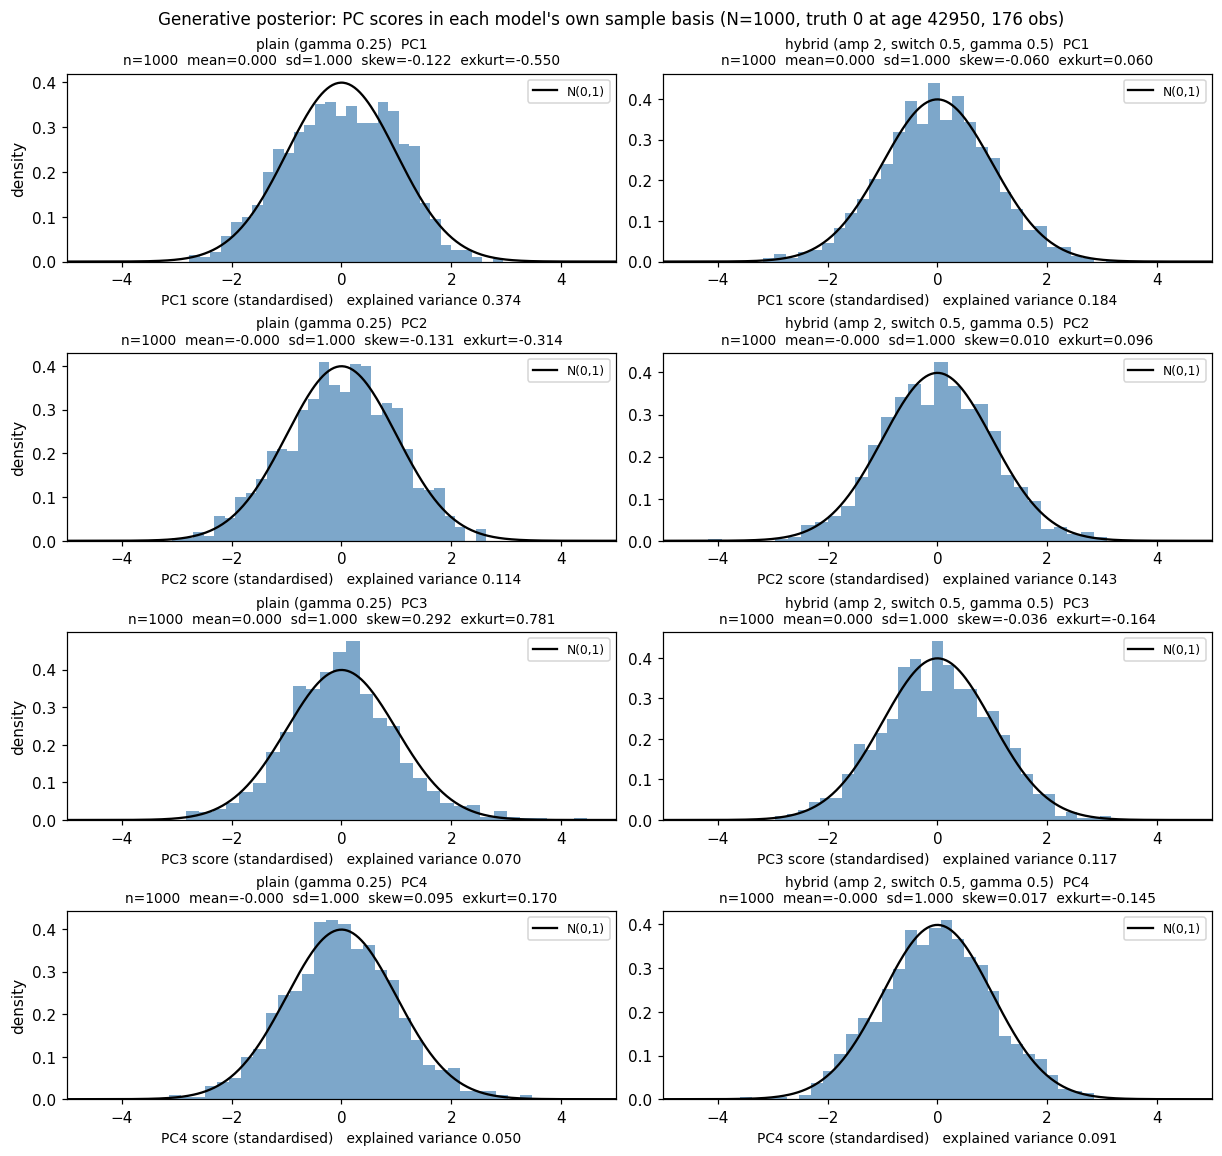

posterior | plain (gamma 0.25): PC1 evr 0.374 skew -0.12 exkurt -0.55 | PC2 evr 0.114 skew -0.13 exkurt -0.31 | PC3 evr 0.070 skew +0.29 exkurt +0.78 | PC4 evr 0.050 skew +0.09 exkurt +0.17
posterior | hybrid (amp 2, switch 0.5, gamma 0.5): PC1 evr 0.184 skew -0.06 exkurt +0.06 | PC2 evr 0.143 skew +0.01 exkurt +0.10 | PC3 evr 0.117 skew -0.04 exkurt -0.16 | PC4 evr 0.091 skew +0.02 exkurt -0.14


In [7]:
import json

from scipy import stats as _st

from paleoreco.assim.experiments import _obs_geometry
from paleoreco.assim.observations import observations_at_age
from paleoreco.eval.projection import orient_pcs, pca_scores, plot_pc_score_distributions

N_PC_SAMPLES, N_PC, PC_TRUTH = 1000, 4, 0
_gd, _hd = OUT / "generative", OUT / "generative_hybrid"

# Keyed on the artefacts rather than on LANES, so the figures can be redrawn from a
# finished run without re-running the lane that produced it.
if (_hd / "ppe_analysis.npz").exists():
    _name = LANE_PRIOR["ppe"]
    _safe, _scales = FRAME[_name][0], FRAME[_name][1]

    # Each model at its own selected operating point, read from its own config:
    # the plain lane's gamma, the hybrid's (amp, switch, gamma). The hybrid's
    # sampler is rebuilt here, so this cell does not depend on the locals of the
    # selection-surface cell above.
    MODELS = {}
    if (_gd / "ppe_config.json").exists():
        _gam = json.load(open(_gd / "ppe_config.json"))["selected"]["b_scale"]
        MODELS[f"plain (gamma {_gam:g})"] = (SAMPLER[_name], _gam)
    _win = json.load(open(_hd / "ppe_config.json"))["selected"]
    _cov_w = COV[_name].scaled(_win["hybrid_amp"])
    MODELS[f"hybrid (amp {_win['hybrid_amp']:g}, switch {_win['hybrid_switch']:g}, "
           f"gamma {_win['b_scale']:g})"] = (
        GuidedSampler(HybridDenoiser(SAMPLER[_name].denoiser, _cov_w,
                                     _win["hybrid_switch"]),
                      _scales, _safe, _cov_w, **SAMPLER_KW),
        _win["b_scale"])

    def draw_prior(sampler, n, seed=0, batch=MAX_BATCH):
        """``n`` unconditional draws; sample_prior takes no max_batch of its own."""
        return np.concatenate([sampler.sample_prior(min(batch, n - k), seed=seed + k)
                               for k in range(0, n, batch)])

    # One assimilation, shared by every model so the posterior columns are paired:
    # truth PC_TRUTH's held-out test network (the last of its drawn shapes) and the
    # pseudo-observations the lane builds for it.
    _z = np.load(_hd / "ppe_analysis.npz")
    _safe_flat = np.broadcast_to(_safe, (len(VARS), *_safe.shape)).ravel()
    _age = int(_z["drawn_ages"][PC_TRUTH, -1])
    _geom = _obs_geometry(observations_at_age(long_ppe, _age), lats, lons, _safe_flat)
    _rng = np.random.default_rng(0)
    _y = (_z["truth_anom"][PC_TRUTH].ravel()[_geom["gather"]]
          + np.mean([_rng.normal(0.0, np.sqrt(_geom["sse"])) for _ in range(5)], axis=0))

    # Fit each model's PCs on its own samples, over valid cells and both channels.
    RES_PC = {"prior": {}, "posterior": {}}
    for _label, (_samp, _gamma) in MODELS.items():
        RES_PC["prior"][_label] = orient_pcs(pca_scores(
            draw_prior(_samp, N_PC_SAMPLES, seed=5000)[:, :, _safe], N_PC))
        RES_PC["posterior"][_label] = orient_pcs(pca_scores(
            _samp.sample_posterior(_geom["gather"], _y, _geom["sse"], _gamma,
                                   N_PC_SAMPLES, seed=6000)[:, :, _safe], N_PC))

    for _split, _res in RES_PC.items():
        _where = (f", truth {PC_TRUTH} at age {_age}, {len(_geom['gather'])} obs"
                  if _split == "posterior" else "")
        plot_pc_score_distributions(
            _res, n_components=N_PC,
            title=(f"Generative {_split}: PC scores in each model's own sample basis "
                   f"(N={N_PC_SAMPLES}{_where})"),
            save_path=str(FIG / f"pc_marginals_{_split}.png"))
        plt.show()
        for _label, _r in _res.items():
            _sc = _r["scores"]
            print(f"{_split:9s} | {_label}: " + " | ".join(
                f"PC{k + 1} evr {_r['explained_variance_ratio'][k]:.3f} "
                f"skew {_st.skew(_sc[:, k]):+.2f} exkurt {_st.kurtosis(_sc[:, k]):+.2f}"
                for k in range(N_PC)))

## Prior vs posterior

The gamma tuning curve, the prior-to-posterior variance reduction (reused from the
3DVar diagnostic), and the pointwise prior/posterior distribution at a cell near a
site and one far from any site.

The tuning curve plots `rrmse_ens`, the surface `gamma` was actually selected on:
plain RRMSE carries the finite-ensemble term `mean(post_var) / K`, which grows with
`gamma` and so tilts the curve toward the small end.

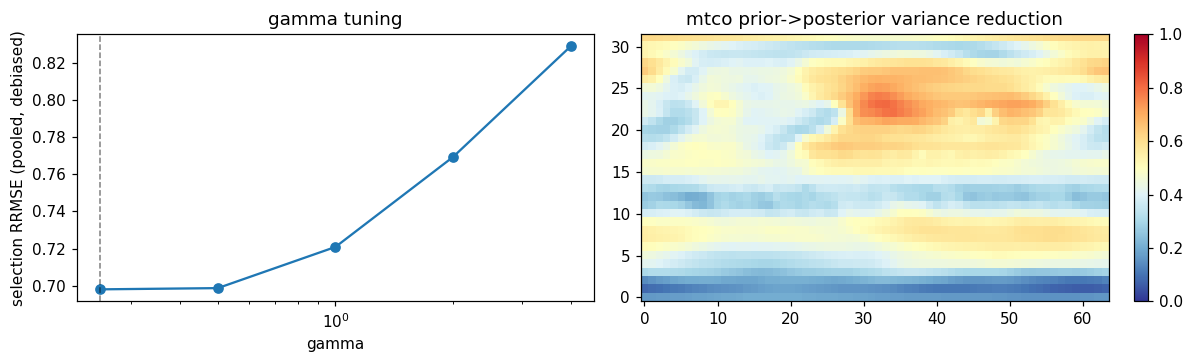

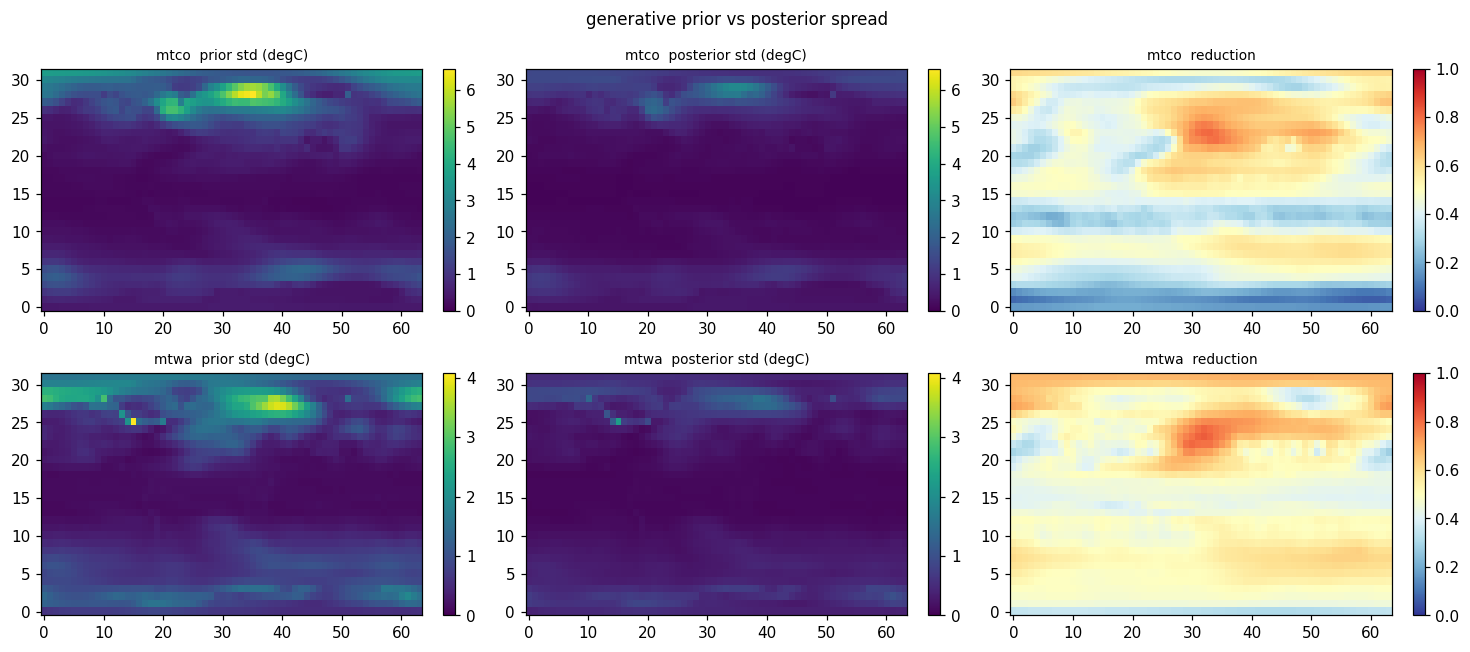

In [10]:
if "ppe" in LANES:
    M = pd.read_csv(OUT / "generative" / "metrics.csv")
    sel = M[(M.lane == "ppe") & (M.split == "selection") & (M.channel == "pooled")
            & (M.do_event == "all") & (M.metric == "rrmse_ens")].sort_values("b_scale")

    z = np.load(OUT / "generative" / "ppe_analysis.npz")
    safe_ppe = z["safe_valid"]
    fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
    ax[0].plot(sel["b_scale"], sel["value"], "o-"); ax[0].set_xscale("log")
    ax[0].axvline(float(z["b_scales"][0]), color="k", lw=1, ls="--", alpha=0.5)
    ax[0].set_xlabel("gamma"); ax[0].set_ylabel("selection RRMSE (pooled, debiased)")
    ax[0].set_title("gamma tuning")

    red = da.uncertainty_reduction(z["prior_ens_var"], z["post_var"][0].mean(axis=0))
    im = ax[1].imshow(np.where(safe_ppe, red[0], np.nan), origin="lower", cmap="RdYlBu_r",
                      vmin=0, vmax=1, aspect="auto")
    ax[1].set_title("mtco prior->posterior variance reduction")
    fig.colorbar(im, ax=ax[1], fraction=0.046)
    fig.tight_layout()
    fig.savefig(FIG / "gamma_and_variance_reduction.png", bbox_inches="tight")
    plt.show()

    da.plot_prior_posterior_uncertainty(
        z["prior_ens_var"], z["post_var"][0].mean(axis=0), safe_ppe, VARS,
        title="generative prior vs posterior spread",
        save_path=str(FIG / "uncertainty_reduction_generative.png"))
    plt.show()

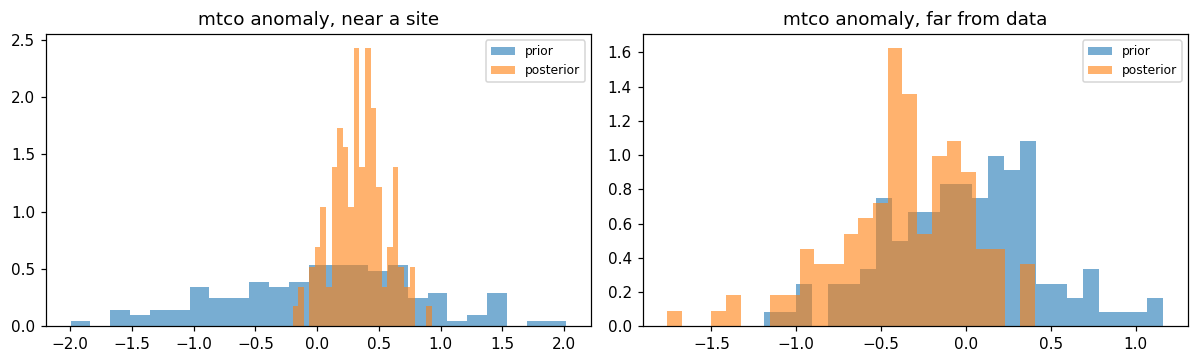

In [11]:
# Pointwise prior vs posterior at a near-site and a far cell (mtco), for one truth.
from paleoreco.assim.observations import observations_at_age
from paleoreco.assim.experiments import _obs_geometry

if "ppe" in LANES:
    samp = SAMPLER[LANE_PRIOR["ppe"]]
    n_cells = len(lats) * len(lons)
    safe_flat = np.broadcast_to(safe_ppe, (len(VARS), *safe_ppe.shape)).ravel()
    age0 = int(z["drawn_ages"][0, -1])
    geom = _obs_geometry(observations_at_age(long_ppe, age0), lats, lons, safe_flat)
    y0 = z["truth_anom"][0].ravel()[geom["gather"]]
    gamma_star = float(z["b_scales"][0])
    post = samp.sample_posterior(geom["gather"], y0, geom["sse"], gamma_star, 128, seed=1)
    prior = samp.sample_prior(128, seed=2)

    # Index the mtco channel (cells 0..n_cells-1) at an observed site and at the void.
    near = int(geom["gather"][0]) % n_cells
    far = int(np.argmax(da.nearest_obs_distance(lats, lons, geom["lat"], geom["lon"])))
    fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
    for a, (cell, label) in zip(ax, ((near, "near a site"), (far, "far from data"))):
        a.hist(prior.reshape(128, -1)[:, cell], bins=25, density=True, alpha=0.6,
               label="prior")
        a.hist(post.reshape(128, -1)[:, cell], bins=25, density=True, alpha=0.6,
               label="posterior")
        a.set_title(f"mtco anomaly, {label}"); a.legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(FIG / "pointwise_prior_posterior.png", bbox_inches="tight")
    plt.show()

## Reading

The cross-method comparison against 3DVar (skill, calibration, prior-to-posterior,
gallery) lives in `09_da_comparison`, which discovers `outputs/da/generative/` and
`outputs/da/generative_hybrid/` automatically.

Two things to read first in the per-cell frame. The generated per-cell std map should
now track the real one in amplitude as well as pattern, since the scale field carries
it rather than the network. And the calibration rows in notebook 09 are where the
change should show up if it helps: an under-dispersed prior was the mechanism behind
the posterior's overconfidence.